In [4]:
import os

#  project folders
folders = [
    "data/raw",
    "data/generated",
    "data/processed",
    "src",
    "results/benchmarks",
    "results/models",
    "results/plots",
    "results/reports",
    "tests"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(" Project folders created successfully")

 Project folders created successfully


Datasets_generation

In [5]:
code = """
import numpy as np


class DataGenerator:
    def __init__(self, seed: int = 42):
        self.rng = np.random.default_rng(seed)

    def uniform(self, n: int, low: int = 0, high: int = 100000) -> np.ndarray:
        return self.rng.integers(low, high, size=n)

    def duplicate_heavy(self, n: int, unique_values: int = 10) -> np.ndarray:
        return self.rng.integers(0, unique_values, size=n)

    def nearly_sorted(self, n: int, swap_fraction: float = 0.05) -> np.ndarray:
        arr = np.sort(self.rng.integers(0, 100000, size=n))
        swaps = max(1, int(n * swap_fraction))
        for _ in range(swaps):
            i, j = self.rng.integers(0, n, size=2)
            arr[i], arr[j] = arr[j], arr[i]
        return arr

    def reverse_sorted(self, n: int) -> np.ndarray:
        return np.sort(self.rng.integers(0, 100000, size=n))[::-1]

    def skewed(self, n: int) -> np.ndarray:
        return self.rng.zipf(a=2.0, size=n)
"""

with open("src/data_generator.py", "w") as f:
    f.write(code)

print("data_generator.py created")

data_generator.py created


Testing data_generator

In [6]:
from src.data_generator import DataGenerator

gen = DataGenerator(seed=42)

arr1 = gen.uniform(10)
arr2 = gen.duplicate_heavy(10)
arr3 = gen.nearly_sorted(10)
arr4 = gen.reverse_sorted(10)
arr5 = gen.skewed(10)

print("Uniform:", arr1)
print("Duplicate-heavy:", arr2)
print("Nearly sorted:", arr3)
print("Reverse sorted:", arr4)
print("Skewed:", arr5)

Uniform: [ 8925 77395 65457 43887 43301 85859  8594 69736 20146  9417]
Duplicate-heavy: [5 9 7 7 7 7 5 1 8 4]
Nearly sorted: [18254 37079 50035 44341 40241 54542 64386 78156 82276 92676]
Reverse sorted: [88788 85829 82763 75808 63166 55458 27675 16522  9213  6381]
Skewed: [ 1  1  1 30  1  1  1  3  1  5]


Saving the generated data

In [7]:
import numpy as np
from src.data_generator import DataGenerator

gen = DataGenerator(seed=42)

sample_data = {
    "uniform_100": gen.uniform(100),
    "duplicate_heavy_100": gen.duplicate_heavy(100),
    "nearly_sorted_100": gen.nearly_sorted(100),
    "reverse_sorted_100": gen.reverse_sorted(100),
    "skewed_100": gen.skewed(100)
}

for name, arr in sample_data.items():
    np.save(f"data/generated/{name}.npy", arr)

print(" Sample datasets saved in data/generated/")

 Sample datasets saved in data/generated/


CPU sorting

In [8]:
code = """
import numpy as np
import time


def cpu_sort(arr: np.ndarray):
    start = time.perf_counter()
    sorted_arr = np.sort(arr)
    end = time.perf_counter()
    return sorted_arr, end - start
"""

with open("src/cpu_sort.py", "w") as f:
    f.write(code)

print("cpu_sort.py created")

cpu_sort.py created


In [9]:
import numpy as np
from src.cpu_sort import cpu_sort
from src.data_generator import DataGenerator

gen = DataGenerator()

arr = gen.uniform(10000)

sorted_arr, time_taken = cpu_sort(arr)

print("Time taken (CPU):", time_taken)
print("Is sorted correctly:", np.all(sorted_arr[:-1] <= sorted_arr[1:]))
print("First 20 sorted elements:", sorted_arr[:20])

Time taken (CPU): 0.0006125849999989441
Is sorted correctly: True
First 20 sorted elements: [  0  41  51  56  64  82  92  98  99 106 123 124 135 153 154 163 166 166
 192 223]


GPU Availability in Colab

In [10]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type > GPU")

CUDA available: True
GPU name: Tesla T4


Installing cuPy for GPU sorting

In [11]:
!pip install -q cupy-cuda12x

In [12]:
code = """
import time
import cupy as cp
import numpy as np


def gpu_sort(arr: np.ndarray):
    start_total = time.perf_counter()

    # Host → Device transfer
    start_h2d = time.perf_counter()
    d_arr = cp.asarray(arr)
    cp.cuda.Stream.null.synchronize()
    end_h2d = time.perf_counter()

    # GPU sort
    start_kernel = time.perf_counter()
    d_sorted = cp.sort(d_arr)
    cp.cuda.Stream.null.synchronize()
    end_kernel = time.perf_counter()

    # Device → Host transfer
    start_d2h = time.perf_counter()
    sorted_arr = cp.asnumpy(d_sorted)
    cp.cuda.Stream.null.synchronize()
    end_d2h = time.perf_counter()

    end_total = time.perf_counter()

    return {
        "sorted_arr": sorted_arr,
        "h2d_time": end_h2d - start_h2d,
        "kernel_time": end_kernel - start_kernel,
        "d2h_time": end_d2h - start_d2h,
        "total_time": end_total - start_total,
    }
"""

with open("src/gpu_sort.py", "w") as f:
    f.write(code)

print("gpu_sort.py created")

gpu_sort.py created


In [13]:
import numpy as np
from src.gpu_sort import gpu_sort
from src.data_generator import DataGenerator

gen = DataGenerator()

arr = gen.uniform(10000)

gpu_result = gpu_sort(arr)

print("H2D time:", gpu_result["h2d_time"])
print("Kernel time:", gpu_result["kernel_time"])
print("D2H time:", gpu_result["d2h_time"])
print("Total GPU time:", gpu_result["total_time"])

print("Is sorted correctly:", np.all(gpu_result["sorted_arr"][:-1] <= gpu_result["sorted_arr"][1:]))
print("First 20 sorted elements:", gpu_result["sorted_arr"][:20])

H2D time: 0.22816794999999956
Kernel time: 0.5684868179999967
D2H time: 0.00019392899997683344
Total GPU time: 0.7968508399999905
Is sorted correctly: True
First 20 sorted elements: [  0  41  51  56  64  82  92  98  99 106 123 124 135 153 154 163 166 166
 192 223]


In [14]:
import numpy as np
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort
from src.data_generator import DataGenerator

gen = DataGenerator()

arr = gen.uniform(10000)

cpu_sorted, cpu_time = cpu_sort(arr)
gpu_result = gpu_sort(arr)

print("CPU time:", cpu_time)
print("GPU total time:", gpu_result["total_time"])
print("GPU H2D time:", gpu_result["h2d_time"])
print("GPU kernel time:", gpu_result["kernel_time"])
print("GPU D2H time:", gpu_result["d2h_time"])

print("CPU and GPU outputs same:", np.array_equal(cpu_sorted, gpu_result["sorted_arr"]))

if cpu_time < gpu_result["total_time"]:
    print("Best engine for this input: CPU")
else:
    print("Best engine for this input: GPU")

CPU time: 0.0002667800000040188
GPU total time: 0.0011550259999921764
GPU H2D time: 0.0003775959999643419
GPU kernel time: 0.0005951320000008309
GPU D2H time: 0.00018068699995410498
CPU and GPU outputs same: True
Best engine for this input: CPU


Feature extractor

In [15]:
code = """
import numpy as np
from scipy.stats import entropy, skew


def duplicate_ratio(arr: np.ndarray) -> float:
    unique_count = len(np.unique(arr))
    return 1.0 - (unique_count / len(arr))


def sortedness_score(arr: np.ndarray, sample_size: int = 1000) -> float:
    n = len(arr)
    if n < 2:
        return 1.0

    idx = np.linspace(0, n - 2, min(sample_size, n - 1), dtype=int)
    ordered = np.sum(arr[idx] <= arr[idx + 1])
    return ordered / len(idx)


def entropy_estimate(arr: np.ndarray) -> float:
    sample = arr[: min(len(arr), 10000)]
    _, counts = np.unique(sample, return_counts=True)
    probs = counts / counts.sum()
    return float(entropy(probs))


def extract_features(arr: np.ndarray) -> dict:
    arr_float = arr.astype(np.float64)

    return {
        "n": int(len(arr)),
        "mean": float(np.mean(arr_float)),
        "std": float(np.std(arr_float)),
        "skewness": float(skew(arr_float)) if len(arr) > 2 else 0.0,
        "duplicate_ratio": float(duplicate_ratio(arr)),
        "sortedness": float(sortedness_score(arr)),
        "entropy": float(entropy_estimate(arr)),
        "memory_bytes": int(arr.nbytes),
    }
"""

with open("src/feature_extractor.py", "w") as f:
    f.write(code)

print("feature_extractor.py created")

feature_extractor.py created


In [16]:
from src.feature_extractor import extract_features
from src.data_generator import DataGenerator

gen = DataGenerator()

arr = gen.duplicate_heavy(10000)
features = extract_features(arr)

for key, value in features.items():
    print(f"{key}: {value}")

n: 10000
mean: 4.4662
std: 2.859800265752838
skewness: 0.02026974967061532
duplicate_ratio: 0.999
sortedness: 0.545
entropy: 2.302047671650409
memory_bytes: 80000


BennchMark

In [17]:
code = """
import numpy as np
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort
from src.feature_extractor import extract_features


def benchmark_one(arr: np.ndarray) -> dict:
    cpu_sorted, cpu_time = cpu_sort(arr)
    gpu_result = gpu_sort(arr)

    assert np.array_equal(cpu_sorted, gpu_result["sorted_arr"]), "CPU and GPU outputs differ"

    best_engine = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

    record = extract_features(arr)
    record.update({
        "cpu_time": cpu_time,
        "gpu_h2d_time": gpu_result["h2d_time"],
        "gpu_kernel_time": gpu_result["kernel_time"],
        "gpu_d2h_time": gpu_result["d2h_time"],
        "gpu_total_time": gpu_result["total_time"],
        "best_engine": best_engine
    })
    return record
"""

with open("src/benchmark.py", "w") as f:
    f.write(code)

print("benchmark.py created")

benchmark.py created


In [18]:
from src.benchmark import benchmark_one
from src.data_generator import DataGenerator

gen = DataGenerator()

arr = gen.uniform(10000)

record = benchmark_one(arr)

for key, value in record.items():
    print(f"{key}: {value}")

n: 10000
mean: 49637.0212
std: 28731.11418011405
skewness: 0.024633680014426795
duplicate_ratio: 0.0494
sortedness: 0.498
entropy: 9.140967908692454
memory_bytes: 80000
cpu_time: 0.00013692200002424215
gpu_h2d_time: 0.0006838070000299012
gpu_kernel_time: 0.0004243239999937032
gpu_d2h_time: 0.0021531079999590474
gpu_total_time: 0.0032648170000015853
best_engine: CPU


Generating multiple workloads and save benchmark CSV

In [19]:
import pandas as pd
from src.data_generator import DataGenerator
from src.benchmark import benchmark_one

gen = DataGenerator(seed=42)

workloads = [
    ("uniform", gen.uniform(1000)),
    ("uniform", gen.uniform(10000)),
    ("uniform", gen.uniform(50000)),
    ("duplicate_heavy", gen.duplicate_heavy(1000)),
    ("duplicate_heavy", gen.duplicate_heavy(10000)),
    ("duplicate_heavy", gen.duplicate_heavy(50000)),
    ("nearly_sorted", gen.nearly_sorted(1000)),
    ("nearly_sorted", gen.nearly_sorted(10000)),
    ("nearly_sorted", gen.nearly_sorted(50000)),
    ("reverse_sorted", gen.reverse_sorted(1000)),
    ("reverse_sorted", gen.reverse_sorted(10000)),
    ("reverse_sorted", gen.reverse_sorted(50000)),
    ("skewed", gen.skewed(1000)),
    ("skewed", gen.skewed(10000)),
    ("skewed", gen.skewed(50000)),
]

records = []

for i, (dist_name, arr) in enumerate(workloads, start=1):
    print(f"Running workload {i}/{len(workloads)}: {dist_name}, size={len(arr)}")
    rec = benchmark_one(arr)
    rec["distribution"] = dist_name
    records.append(rec)

df = pd.DataFrame(records)
df.to_csv("results/benchmarks/benchmark_dataset_v1.csv", index=False)

print("\n Benchmark dataset saved to results/benchmarks/benchmark_dataset_v1.csv")
print("\nPreview:")
print(df.head())

Running workload 1/15: uniform, size=1000
Running workload 2/15: uniform, size=10000
Running workload 3/15: uniform, size=50000
Running workload 4/15: duplicate_heavy, size=1000
Running workload 5/15: duplicate_heavy, size=10000
Running workload 6/15: duplicate_heavy, size=50000
Running workload 7/15: nearly_sorted, size=1000
Running workload 8/15: nearly_sorted, size=10000
Running workload 9/15: nearly_sorted, size=50000
Running workload 10/15: reverse_sorted, size=1000
Running workload 11/15: reverse_sorted, size=10000
Running workload 12/15: reverse_sorted, size=50000
Running workload 13/15: skewed, size=1000
Running workload 14/15: skewed, size=10000
Running workload 15/15: skewed, size=50000

 Benchmark dataset saved to results/benchmarks/benchmark_dataset_v1.csv

Preview:
       n         mean           std  skewness  duplicate_ratio  sortedness  \
0   1000  50300.09700  28847.116956 -0.030480           0.0040    0.498498   
1  10000  49560.25370  28733.651900  0.031062          

Load Benchmark CSV

In [20]:
import pandas as pd

# Load benchmark dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v1.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nBest engine counts:")
print(df["best_engine"].value_counts())

print("\nPreview:")
print(df.head())

Dataset shape: (15, 15)

Columns:
['n', 'mean', 'std', 'skewness', 'duplicate_ratio', 'sortedness', 'entropy', 'memory_bytes', 'cpu_time', 'gpu_h2d_time', 'gpu_kernel_time', 'gpu_d2h_time', 'gpu_total_time', 'best_engine', 'distribution']

Best engine counts:
best_engine
CPU    13
GPU     2
Name: count, dtype: int64

Preview:
       n         mean           std  skewness  duplicate_ratio  sortedness  \
0   1000  50300.09700  28847.116956 -0.030480           0.0040    0.498498   
1  10000  49560.25370  28733.651900  0.031062           0.0498    0.487000   
2  50000  50051.78834  28882.615941 -0.003769           0.2131    0.480000   
3   1000      4.65800      2.868630 -0.078328           0.9900    0.548549   
4  10000      4.46050      2.866852  0.016523           0.9990    0.543000   

    entropy  memory_bytes  cpu_time  gpu_h2d_time  gpu_kernel_time  \
0  6.902210          8000  0.000031      0.002391         0.000348   
1  9.140361         80000  0.000121      0.000170         0.000

Training ML Selector

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Input features
feature_cols = [
    "n",
    "mean",
    "std",
    "skewness",
    "duplicate_ratio",
    "sortedness",
    "entropy",
    "memory_bytes"
]

X = df[feature_cols]
y = df["best_engine"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

         CPU       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
 [[3]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [22]:
import os
import joblib
import pandas as pd

# Feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Feature Importance:\n")
print(importance_df)

# Save model
os.makedirs("results/models", exist_ok=True)
joblib.dump(model, "results/models/runtime_selector_rf.joblib")

print("\nModel saved to results/models/runtime_selector_rf.joblib")

Feature Importance:

           feature  importance
1             mean    0.217195
5       sortedness    0.159516
6          entropy    0.142967
2              std    0.115777
0                n    0.107579
3         skewness    0.086329
4  duplicate_ratio    0.086111
7     memory_bytes    0.084525

Model saved to results/models/runtime_selector_rf.joblib


In [23]:
print("Best engine counts:")
print(df["best_engine"].value_counts())

print("\nUnique classes:")
print(df["best_engine"].unique())

Best engine counts:
best_engine
CPU    13
GPU     2
Name: count, dtype: int64

Unique classes:
['CPU' 'GPU']


In [24]:
import pandas as pd
from src.data_generator import DataGenerator
from src.benchmark import benchmark_one
import numpy as np

gen = DataGenerator(seed=42)

sizes = [1000, 5000, 10000, 50000, 100000, 200000]
distributions = [
    ("uniform", gen.uniform),
    ("duplicate_heavy", gen.duplicate_heavy),
    ("nearly_sorted", gen.nearly_sorted),
    ("reverse_sorted", gen.reverse_sorted),
    ("skewed", gen.skewed),
]

records = []

total_runs = len(sizes) * len(distributions) * 3
run_id = 1

for size in sizes:
    for name, func in distributions:
        for _ in range(3):  # repeat for randomness
            print(f"Run {run_id}/{total_runs} → {name}, size={size}")

            arr = func(size)
            rec = benchmark_one(arr)
            rec["distribution"] = name
            rec["size"] = size

            records.append(rec)
            run_id += 1

df = pd.DataFrame(records)

df.to_csv("results/benchmarks/benchmark_dataset_v2.csv", index=False)

print("\n New dataset saved: benchmark_dataset_v2.csv")
print("\nClass distribution:")
print(df["best_engine"].value_counts())

Run 1/90 → uniform, size=1000
Run 2/90 → uniform, size=1000
Run 3/90 → uniform, size=1000
Run 4/90 → duplicate_heavy, size=1000
Run 5/90 → duplicate_heavy, size=1000
Run 6/90 → duplicate_heavy, size=1000
Run 7/90 → nearly_sorted, size=1000
Run 8/90 → nearly_sorted, size=1000
Run 9/90 → nearly_sorted, size=1000
Run 10/90 → reverse_sorted, size=1000
Run 11/90 → reverse_sorted, size=1000
Run 12/90 → reverse_sorted, size=1000
Run 13/90 → skewed, size=1000
Run 14/90 → skewed, size=1000
Run 15/90 → skewed, size=1000
Run 16/90 → uniform, size=5000
Run 17/90 → uniform, size=5000
Run 18/90 → uniform, size=5000
Run 19/90 → duplicate_heavy, size=5000
Run 20/90 → duplicate_heavy, size=5000
Run 21/90 → duplicate_heavy, size=5000
Run 22/90 → nearly_sorted, size=5000
Run 23/90 → nearly_sorted, size=5000
Run 24/90 → nearly_sorted, size=5000
Run 25/90 → reverse_sorted, size=5000
Run 26/90 → reverse_sorted, size=5000
Run 27/90 → reverse_sorted, size=5000
Run 28/90 → skewed, size=5000
Run 29/90 → skewed,

In [25]:
import pandas as pd
from src.data_generator import DataGenerator
from src.benchmark import benchmark_one

gen = DataGenerator(seed=42)

# Bigger sizes → GPU advantage
sizes = [300000, 500000, 800000, 1000000]

records = []

for size in sizes:
    for _ in range(2):
        print(f"Generating large workload size={size}")

        arr = gen.uniform(size)
        rec = benchmark_one(arr)
        rec["distribution"] = "uniform_large"
        rec["size"] = size

        records.append(rec)

df_large = pd.DataFrame(records)

# Load previous dataset
df_old = pd.read_csv("results/benchmarks/benchmark_dataset_v2.csv")

# Combine
df_final = pd.concat([df_old, df_large], ignore_index=True)

df_final.to_csv("results/benchmarks/benchmark_dataset_v3.csv", index=False)

print("\nFinal dataset saved: benchmark_dataset_v3.csv")
print("\nNew class distribution:")
print(df_final["best_engine"].value_counts())

Generating large workload size=300000
Generating large workload size=300000
Generating large workload size=500000
Generating large workload size=500000
Generating large workload size=800000
Generating large workload size=800000
Generating large workload size=1000000
Generating large workload size=1000000

Final dataset saved: benchmark_dataset_v3.csv

New class distribution:
best_engine
CPU    86
GPU    12
Name: count, dtype: int64


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load final dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v3.csv")

feature_cols = [
    "n",
    "mean",
    "std",
    "skewness",
    "duplicate_ratio",
    "sortedness",
    "entropy",
    "memory_bytes"
]

X = df[feature_cols]
y = df["best_engine"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# class_weight helps because GPU class is smaller
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

         CPU       0.94      0.83      0.88        18
         GPU       0.25      0.50      0.33         2

    accuracy                           0.80        20
   macro avg       0.59      0.67      0.61        20
weighted avg       0.87      0.80      0.83        20

Confusion Matrix:
 [[15  3]
 [ 1  1]]


In [27]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Feature Importance:\n")
print(importance_df)

Feature Importance:

           feature  importance
7     memory_bytes    0.212501
0                n    0.203191
2              std    0.149016
4  duplicate_ratio    0.107997
6          entropy    0.107929
1             mean    0.100693
5       sortedness    0.069399
3         skewness    0.049274


Runtime prediction

In [28]:
from src.feature_extractor import extract_features
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort
from src.data_generator import DataGenerator
import pandas as pd

gen = DataGenerator()

# Try different workloads
arr = gen.uniform(120000)   # you can change this later

# Extract features
features = extract_features(arr)
X_input = pd.DataFrame([features])

# Predict best engine
prediction = model.predict(X_input)[0]

print("Predicted best engine:", prediction)

# Execute based on prediction
if prediction == "CPU":
    sorted_arr, time_taken = cpu_sort(arr)
    print("Executed on CPU")
    print("Time:", time_taken)
else:
    result = gpu_sort(arr)
    print("Executed on GPU")
    print("Time:", result["total_time"])

# Verify correctness
print("Sorted correctly:", all(sorted_arr[i] <= sorted_arr[i+1] for i in range(len(sorted_arr)-1)))

Predicted best engine: CPU
Executed on CPU
Time: 0.0014412579999998343
Sorted correctly: True


In [29]:
from src.feature_extractor import extract_features
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort
from src.data_generator import DataGenerator
import pandas as pd
import numpy as np

gen = DataGenerator()

# Change this later to test different workloads
arr = gen.uniform(120000)

# Step 1: Predict best engine
features = extract_features(arr)
X_input = pd.DataFrame([features])
prediction = model.predict(X_input)[0]

print("Predicted best engine:", prediction)

# Step 2: Run predicted path
if prediction == "CPU":
    pred_sorted_arr, pred_time = cpu_sort(arr)
    print("Executed on CPU")
    print("Predicted-path time:", pred_time)
else:
    gpu_pred_result = gpu_sort(arr)
    pred_sorted_arr = gpu_pred_result["sorted_arr"]
    pred_time = gpu_pred_result["total_time"]
    print("Executed on GPU")
    print("Predicted-path time:", pred_time)

# Step 3: Run both engines for ground-truth comparison
cpu_sorted, cpu_time = cpu_sort(arr)
gpu_result = gpu_sort(arr)

actual_best = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

print("\n--- Ground Truth Comparison ---")
print("CPU time:", cpu_time)
print("GPU total time:", gpu_result["total_time"])
print("Actual best engine:", actual_best)

# Step 4: Accuracy for this single test
print("\nPrediction correct:", prediction == actual_best)

# Step 5: Correctness check
print("CPU output correct:", np.all(cpu_sorted[:-1] <= cpu_sorted[1:]))
print("GPU output correct:", np.all(gpu_result["sorted_arr"][:-1] <= gpu_result["sorted_arr"][1:]))
print("CPU and GPU outputs same:", np.array_equal(cpu_sorted, gpu_result["sorted_arr"]))

Predicted best engine: CPU
Executed on CPU
Predicted-path time: 0.0014249940000468087

--- Ground Truth Comparison ---
CPU time: 0.0009783159999869895
GPU total time: 0.0012927269999636337
Actual best engine: CPU

Prediction correct: True
CPU output correct: True
GPU output correct: True
CPU and GPU outputs same: True


Test the scheduler on multiple workloads automatically

In [30]:
import pandas as pd
import numpy as np
from src.data_generator import DataGenerator
from src.feature_extractor import extract_features
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort

gen = DataGenerator(seed=123)

test_workloads = [
    ("uniform", gen.uniform(1000)),
    ("uniform", gen.uniform(10000)),
    ("uniform", gen.uniform(100000)),
    ("duplicate_heavy", gen.duplicate_heavy(1000)),
    ("duplicate_heavy", gen.duplicate_heavy(10000)),
    ("duplicate_heavy", gen.duplicate_heavy(100000)),
    ("nearly_sorted", gen.nearly_sorted(1000)),
    ("nearly_sorted", gen.nearly_sorted(10000)),
    ("nearly_sorted", gen.nearly_sorted(100000)),
    ("reverse_sorted", gen.reverse_sorted(1000)),
    ("reverse_sorted", gen.reverse_sorted(10000)),
    ("reverse_sorted", gen.reverse_sorted(100000)),
    ("skewed", gen.skewed(1000)),
    ("skewed", gen.skewed(10000)),
    ("skewed", gen.skewed(100000)),
]

results = []

for i, (dist_name, arr) in enumerate(test_workloads, start=1):
    # Predict
    features = extract_features(arr)
    X_input = pd.DataFrame([features])
    prediction = model.predict(X_input)[0]

    # Ground truth
    cpu_sorted, cpu_time = cpu_sort(arr)
    gpu_result = gpu_sort(arr)
    actual_best = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

    results.append({
        "workload_id": i,
        "distribution": dist_name,
        "size": len(arr),
        "predicted_engine": prediction,
        "actual_best_engine": actual_best,
        "prediction_correct": prediction == actual_best,
        "cpu_time": cpu_time,
        "gpu_total_time": gpu_result["total_time"]
    })

results_df = pd.DataFrame(results)

print(results_df)
print("\nOverall accuracy on these test workloads:", results_df["prediction_correct"].mean())

    workload_id     distribution    size predicted_engine actual_best_engine  \
0             1          uniform    1000              CPU                CPU   
1             2          uniform   10000              CPU                CPU   
2             3          uniform  100000              CPU                CPU   
3             4  duplicate_heavy    1000              CPU                CPU   
4             5  duplicate_heavy   10000              CPU                CPU   
5             6  duplicate_heavy  100000              CPU                CPU   
6             7    nearly_sorted    1000              CPU                CPU   
7             8    nearly_sorted   10000              CPU                CPU   
8             9    nearly_sorted  100000              GPU                GPU   
9            10   reverse_sorted    1000              CPU                CPU   
10           11   reverse_sorted   10000              CPU                CPU   
11           12   reverse_sorted  100000

In [31]:
results_df.to_csv("results/reports/runtime_scheduler_test_results.csv", index=False)
print(" Saved: results/reports/runtime_scheduler_test_results.csv")

 Saved: results/reports/runtime_scheduler_test_results.csv


In [32]:
code = """
import pandas as pd
from src.feature_extractor import extract_features
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort


class RuntimeScheduler:
    def __init__(self, model):
        self.model = model

    def predict_engine(self, arr):
        features = extract_features(arr)
        X_input = pd.DataFrame([features])
        prediction = self.model.predict(X_input)[0]
        return prediction, features

    def execute(self, arr):
        prediction, features = self.predict_engine(arr)

        if prediction == "CPU":
            sorted_arr, exec_time = cpu_sort(arr)
            result = {
                "predicted_engine": prediction,
                "execution_time": exec_time,
                "sorted_arr": sorted_arr,
                "features": features
            }
        else:
            gpu_result = gpu_sort(arr)
            result = {
                "predicted_engine": prediction,
                "execution_time": gpu_result["total_time"],
                "sorted_arr": gpu_result["sorted_arr"],
                "features": features,
                "gpu_h2d_time": gpu_result["h2d_time"],
                "gpu_kernel_time": gpu_result["kernel_time"],
                "gpu_d2h_time": gpu_result["d2h_time"]
            }

        return result
"""

with open("src/scheduler.py", "w") as f:
    f.write(code)

print("scheduler.py created")

scheduler.py created


In [33]:
from src.scheduler import RuntimeScheduler
from src.data_generator import DataGenerator
import numpy as np

gen = DataGenerator(seed=42)
scheduler = RuntimeScheduler(model)

arr = gen.uniform(150000)

result = scheduler.execute(arr)

print("Predicted engine:", result["predicted_engine"])
print("Execution time:", result["execution_time"])
print("Sorted correctly:", np.all(result["sorted_arr"][:-1] <= result["sorted_arr"][1:]))

print("\nExtracted features:")
for key, value in result["features"].items():
    print(f"{key}: {value}")

if result["predicted_engine"] == "GPU":
    print("\nGPU timing breakdown:")
    print("H2D time:", result["gpu_h2d_time"])
    print("Kernel time:", result["gpu_kernel_time"])
    print("D2H time:", result["gpu_d2h_time"])

Predicted engine: CPU
Execution time: 0.0016447290000201065
Sorted correctly: True

Extracted features:
n: 150000
mean: 50048.716726666666
std: 28851.05500207025
skewness: -0.0012472530081601395
duplicate_ratio: 0.4821266666666667
sortedness: 0.506
entropy: 9.140967908692454
memory_bytes: 1200000


In [34]:
import joblib
import os

os.makedirs("results/models", exist_ok=True)

joblib.dump(model, "results/models/runtime_selector_rf.joblib")

print("Model saved successfully at: results/models/runtime_selector_rf.joblib")

Model saved successfully at: results/models/runtime_selector_rf.joblib


Load the saved model and test reuse

In [35]:
import joblib
from src.scheduler import RuntimeScheduler
from src.data_generator import DataGenerator
import numpy as np

# Load saved model
loaded_model = joblib.load("results/models/runtime_selector_rf.joblib")

# Create scheduler using loaded model
scheduler_loaded = RuntimeScheduler(loaded_model)

# Test on a new workload
gen = DataGenerator(seed=99)
arr = gen.nearly_sorted(120000)

result = scheduler_loaded.execute(arr)

print("Predicted engine:", result["predicted_engine"])
print("Execution time:", result["execution_time"])
print("Sorted correctly:", np.all(result["sorted_arr"][:-1] <= result["sorted_arr"][1:]))

Predicted engine: CPU
Execution time: 0.00105547199996181
Sorted correctly: True


In [36]:
import pandas as pd
from src.data_generator import DataGenerator
from src.feature_extractor import extract_features
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort

gen = DataGenerator(seed=2026)

large_test_workloads = [
    ("uniform", gen.uniform(200000)),
    ("uniform", gen.uniform(500000)),
    ("uniform", gen.uniform(800000)),
    ("uniform", gen.uniform(1000000)),

    ("duplicate_heavy", gen.duplicate_heavy(200000)),
    ("duplicate_heavy", gen.duplicate_heavy(500000)),
    ("duplicate_heavy", gen.duplicate_heavy(800000)),
    ("duplicate_heavy", gen.duplicate_heavy(1000000)),

    ("nearly_sorted", gen.nearly_sorted(200000)),
    ("nearly_sorted", gen.nearly_sorted(500000)),
    ("nearly_sorted", gen.nearly_sorted(800000)),
    ("nearly_sorted", gen.nearly_sorted(1000000)),

    ("reverse_sorted", gen.reverse_sorted(200000)),
    ("reverse_sorted", gen.reverse_sorted(500000)),
    ("reverse_sorted", gen.reverse_sorted(800000)),
    ("reverse_sorted", gen.reverse_sorted(1000000)),

    ("skewed", gen.skewed(200000)),
    ("skewed", gen.skewed(500000)),
    ("skewed", gen.skewed(800000)),
    ("skewed", gen.skewed(1000000)),
]

large_results = []

for i, (dist_name, arr) in enumerate(large_test_workloads, start=1):
    print(f"Running {i}/{len(large_test_workloads)} -> {dist_name}, size={len(arr)}")

    # prediction
    features = extract_features(arr)
    X_input = pd.DataFrame([features])
    prediction = model.predict(X_input)[0]

    # ground truth
    cpu_sorted, cpu_time = cpu_sort(arr)
    gpu_result = gpu_sort(arr)
    actual_best = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

    large_results.append({
        "workload_id": i,
        "distribution": dist_name,
        "size": len(arr),
        "predicted_engine": prediction,
        "actual_best_engine": actual_best,
        "prediction_correct": prediction == actual_best,
        "cpu_time": cpu_time,
        "gpu_total_time": gpu_result["total_time"],
        "gpu_h2d_time": gpu_result["h2d_time"],
        "gpu_kernel_time": gpu_result["kernel_time"],
        "gpu_d2h_time": gpu_result["d2h_time"]
    })

large_results_df = pd.DataFrame(large_results)

print("\n===== Large Dataset Test Results =====")
print(large_results_df)

print("\nOverall accuracy:", large_results_df["prediction_correct"].mean())

print("\nPredicted engine counts:")
print(large_results_df["predicted_engine"].value_counts())

print("\nActual best engine counts:")
print(large_results_df["actual_best_engine"].value_counts())

Running 1/20 -> uniform, size=200000
Running 2/20 -> uniform, size=500000
Running 3/20 -> uniform, size=800000
Running 4/20 -> uniform, size=1000000
Running 5/20 -> duplicate_heavy, size=200000
Running 6/20 -> duplicate_heavy, size=500000
Running 7/20 -> duplicate_heavy, size=800000
Running 8/20 -> duplicate_heavy, size=1000000
Running 9/20 -> nearly_sorted, size=200000
Running 10/20 -> nearly_sorted, size=500000
Running 11/20 -> nearly_sorted, size=800000
Running 12/20 -> nearly_sorted, size=1000000
Running 13/20 -> reverse_sorted, size=200000
Running 14/20 -> reverse_sorted, size=500000
Running 15/20 -> reverse_sorted, size=800000
Running 16/20 -> reverse_sorted, size=1000000
Running 17/20 -> skewed, size=200000
Running 18/20 -> skewed, size=500000
Running 19/20 -> skewed, size=800000
Running 20/20 -> skewed, size=1000000

===== Large Dataset Test Results =====
    workload_id     distribution     size predicted_engine actual_best_engine  \
0             1          uniform   200000  

In [37]:
import pandas as pd
from src.data_generator import DataGenerator
from src.benchmark import benchmark_one

gen = DataGenerator(seed=42)

sizes = [800000, 1000000, 1500000]

records = []

for size in sizes:
    for _ in range(3):
        print(f"Adding GPU-heavy sample size={size}")

        arr = gen.uniform(size)
        rec = benchmark_one(arr)
        rec["distribution"] = "uniform_large"
        rec["size"] = size

        records.append(rec)

df_extra = pd.DataFrame(records)

# Load old dataset
df_old = pd.read_csv("results/benchmarks/benchmark_dataset_v3.csv")

# Combine
df_new = pd.concat([df_old, df_extra], ignore_index=True)

df_new.to_csv("results/benchmarks/benchmark_dataset_v4.csv", index=False)

print("\nNew class distribution:")
print(df_new["best_engine"].value_counts())

Adding GPU-heavy sample size=800000
Adding GPU-heavy sample size=800000
Adding GPU-heavy sample size=800000
Adding GPU-heavy sample size=1000000
Adding GPU-heavy sample size=1000000
Adding GPU-heavy sample size=1000000
Adding GPU-heavy sample size=1500000
Adding GPU-heavy sample size=1500000
Adding GPU-heavy sample size=1500000

New class distribution:
best_engine
CPU    87
GPU    20
Name: count, dtype: int64


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load new dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v4.csv")

feature_cols = [
    "n",
    "mean",
    "std",
    "skewness",
    "duplicate_ratio",
    "sortedness",
    "entropy",
    "memory_bytes"
]

X = df[feature_cols]
y = df["best_engine"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8636363636363636

Classification Report:

              precision    recall  f1-score   support

         CPU       0.89      0.94      0.92        18
         GPU       0.67      0.50      0.57         4

    accuracy                           0.86        22
   macro avg       0.78      0.72      0.75        22
weighted avg       0.85      0.86      0.86        22



In [39]:
large_results_df = pd.DataFrame(large_results)

print("\n===== Large Dataset Test Results =====")
print(large_results_df)

print("\nOverall accuracy:", large_results_df["prediction_correct"].mean())

print("\nPredicted engine counts:")
print(large_results_df["predicted_engine"].value_counts())

print("\nActual best engine counts:")
print(large_results_df["actual_best_engine"].value_counts())


===== Large Dataset Test Results =====
    workload_id     distribution     size predicted_engine actual_best_engine  \
0             1          uniform   200000              GPU                CPU   
1             2          uniform   500000              CPU                GPU   
2             3          uniform   800000              CPU                GPU   
3             4          uniform  1000000              GPU                GPU   
4             5  duplicate_heavy   200000              CPU                CPU   
5             6  duplicate_heavy   500000              CPU                CPU   
6             7  duplicate_heavy   800000              CPU                CPU   
7             8  duplicate_heavy  1000000              CPU                CPU   
8             9    nearly_sorted   200000              GPU                GPU   
9            10    nearly_sorted   500000              GPU                GPU   
10           11    nearly_sorted   800000              GPU           

In [40]:
import pandas as pd

# Load the improved dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v4.csv")

print("Shape:", df.shape)
print("\nClass counts:")
print(df["best_engine"].value_counts())

print("\nDistributions:")
print(df["distribution"].value_counts())

# One-hot encode distribution
df_encoded = pd.get_dummies(df, columns=["distribution"], drop_first=False)

print("\nEncoded columns:")
print(df_encoded.columns.tolist())

Shape: (107, 16)

Class counts:
best_engine
CPU    87
GPU    20
Name: count, dtype: int64

Distributions:
distribution
uniform            18
duplicate_heavy    18
nearly_sorted      18
reverse_sorted     18
skewed             18
uniform_large      17
Name: count, dtype: int64

Encoded columns:
['n', 'mean', 'std', 'skewness', 'duplicate_ratio', 'sortedness', 'entropy', 'memory_bytes', 'cpu_time', 'gpu_h2d_time', 'gpu_kernel_time', 'gpu_d2h_time', 'gpu_total_time', 'best_engine', 'size', 'distribution_duplicate_heavy', 'distribution_nearly_sorted', 'distribution_reverse_sorted', 'distribution_skewed', 'distribution_uniform', 'distribution_uniform_large']


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Encode target
df_encoded["target"] = df_encoded["best_engine"].map({"CPU": 0, "GPU": 1})

# Drop label columns
X = df_encoded.drop(columns=["best_engine", "target"])
y = df_encoded["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Handle class imbalance
gpu_count = (y_train == 1).sum()
cpu_count = (y_train == 0).sum()
scale_pos_weight = cpu_count / gpu_count

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["CPU", "GPU"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9090909090909091

Classification Report:

              precision    recall  f1-score   support

         CPU       1.00      0.89      0.94        18
         GPU       0.67      1.00      0.80         4

    accuracy                           0.91        22
   macro avg       0.83      0.94      0.87        22
weighted avg       0.94      0.91      0.92        22

Confusion Matrix:
 [[16  2]
 [ 0  4]]


In [42]:
import pandas as pd
from src.data_generator import DataGenerator
from src.benchmark import benchmark_one
import numpy as np

gen = DataGenerator(seed=123)

# Focused sizes around crossover
sizes = [
    600000, 700000, 800000,
    900000, 1000000, 1200000, 1500000
]

records = []

for size in sizes:
    for _ in range(4):  # more samples per size
        print(f"Boundary sample size={size}")

        # mix distributions
        arr = np.random.choice([
            gen.uniform,
            gen.nearly_sorted,
            gen.reverse_sorted
        ])(size)

        rec = benchmark_one(arr)
        rec["distribution"] = "boundary"
        rec["size"] = size

        records.append(rec)

df_boundary = pd.DataFrame(records)

# Load existing dataset
df_old = pd.read_csv("results/benchmarks/benchmark_dataset_v4.csv")

# Combine
df_final = pd.concat([df_old, df_boundary], ignore_index=True)

df_final.to_csv("results/benchmarks/benchmark_dataset_v5.csv", index=False)

print("\nNew class distribution:")
print(df_final["best_engine"].value_counts())

Boundary sample size=600000
Boundary sample size=600000
Boundary sample size=600000
Boundary sample size=600000
Boundary sample size=700000
Boundary sample size=700000
Boundary sample size=700000
Boundary sample size=700000
Boundary sample size=800000
Boundary sample size=800000
Boundary sample size=800000
Boundary sample size=800000
Boundary sample size=900000
Boundary sample size=900000
Boundary sample size=900000
Boundary sample size=900000
Boundary sample size=1000000
Boundary sample size=1000000
Boundary sample size=1000000
Boundary sample size=1000000
Boundary sample size=1200000
Boundary sample size=1200000
Boundary sample size=1200000
Boundary sample size=1200000
Boundary sample size=1500000
Boundary sample size=1500000
Boundary sample size=1500000
Boundary sample size=1500000

New class distribution:
best_engine
CPU    87
GPU    48
Name: count, dtype: int64


In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Load v5 dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v5.csv")

# One-hot encode distribution
df_encoded = pd.get_dummies(df, columns=["distribution"], drop_first=False)

# Target
df_encoded["target"] = df_encoded["best_engine"].map({"CPU": 0, "GPU": 1})

X = df_encoded.drop(columns=["best_engine", "target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Balance weight
gpu_count = (y_train == 1).sum()
cpu_count = (y_train == 0).sum()
scale_pos_weight = cpu_count / gpu_count

# Train stronger model
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["CPU", "GPU"]))

Accuracy: 0.8888888888888888

Classification Report:

              precision    recall  f1-score   support

         CPU       0.89      0.94      0.91        17
         GPU       0.89      0.80      0.84        10

    accuracy                           0.89        27
   macro avg       0.89      0.87      0.88        27
weighted avg       0.89      0.89      0.89        27



In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Load v5 dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v5.csv")

# One-hot encode distribution
df_encoded = pd.get_dummies(df, columns=["distribution"], drop_first=False)

# Target
df_encoded["target"] = df_encoded["best_engine"].map({"CPU": 0, "GPU": 1})

X = df_encoded.drop(columns=["best_engine", "target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Balance weight
gpu_count = (y_train == 1).sum()
cpu_count = (y_train == 0).sum()
scale_pos_weight = cpu_count / gpu_count

# Train stronger model
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["CPU", "GPU"]))

Accuracy: 0.8888888888888888

Classification Report:

              precision    recall  f1-score   support

         CPU       0.89      0.94      0.91        17
         GPU       0.89      0.80      0.84        10

    accuracy                           0.89        27
   macro avg       0.89      0.87      0.88        27
weighted avg       0.89      0.89      0.89        27



In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("results/benchmarks/benchmark_dataset_v5.csv")

# Keep only valid pre-execution columns
runtime_feature_cols = [
    "n",
    "mean",
    "std",
    "skewness",
    "duplicate_ratio",
    "sortedness",
    "entropy",
    "memory_bytes",
    "distribution"
]

df_runtime = df[runtime_feature_cols + ["best_engine"]].copy()

# One-hot encode distribution
X = pd.get_dummies(df_runtime.drop(columns=["best_engine"]), columns=["distribution"], drop_first=False)
y = df_runtime["best_engine"].map({"CPU": 0, "GPU": 1})

# Save training column order for inference later
xgb_feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

gpu_count = (y_train == 1).sum()
cpu_count = (y_train == 0).sum()
scale_pos_weight = cpu_count / gpu_count

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["CPU", "GPU"]))
print("\nTraining feature columns:")
print(xgb_feature_columns)

Accuracy: 0.8518518518518519

Classification Report:

              precision    recall  f1-score   support

         CPU       0.84      0.94      0.89        17
         GPU       0.88      0.70      0.78        10

    accuracy                           0.85        27
   macro avg       0.86      0.82      0.83        27
weighted avg       0.85      0.85      0.85        27


Training feature columns:
['n', 'mean', 'std', 'skewness', 'duplicate_ratio', 'sortedness', 'entropy', 'memory_bytes', 'distribution_boundary', 'distribution_duplicate_heavy', 'distribution_nearly_sorted', 'distribution_reverse_sorted', 'distribution_skewed', 'distribution_uniform', 'distribution_uniform_large']


In [46]:
large_results = []

for i, (dist_name, arr) in enumerate(large_test_workloads, start=1):
    print(f"Running {i}/{len(large_test_workloads)} -> {dist_name}, size={len(arr)}")

    # base runtime features
    features = extract_features(arr)
    features["distribution"] = dist_name

    # one-row dataframe
    X_input = pd.DataFrame([features])

    # one-hot encode distribution
    X_input = pd.get_dummies(X_input, columns=["distribution"], drop_first=False)

    # align with training columns
    X_input = X_input.reindex(columns=xgb_feature_columns, fill_value=0)

    # predict
    prediction = xgb_model.predict(X_input)[0]
    prediction = "GPU" if prediction == 1 else "CPU"

    # ground truth
    cpu_sorted, cpu_time = cpu_sort(arr)
    gpu_result = gpu_sort(arr)
    actual_best = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

    large_results.append({
        "distribution": dist_name,
        "size": len(arr),
        "predicted": prediction,
        "actual": actual_best,
        "correct": prediction == actual_best,
        "cpu_time": cpu_time,
        "gpu_total_time": gpu_result["total_time"]
    })

large_df = pd.DataFrame(large_results)

print("\nResults:\n", large_df)
print("\nAccuracy:", large_df["correct"].mean())
print("\nPredicted counts:")
print(large_df["predicted"].value_counts())
print("\nActual counts:")
print(large_df["actual"].value_counts())

Running 1/20 -> uniform, size=200000
Running 2/20 -> uniform, size=500000
Running 3/20 -> uniform, size=800000
Running 4/20 -> uniform, size=1000000
Running 5/20 -> duplicate_heavy, size=200000
Running 6/20 -> duplicate_heavy, size=500000
Running 7/20 -> duplicate_heavy, size=800000
Running 8/20 -> duplicate_heavy, size=1000000
Running 9/20 -> nearly_sorted, size=200000
Running 10/20 -> nearly_sorted, size=500000
Running 11/20 -> nearly_sorted, size=800000
Running 12/20 -> nearly_sorted, size=1000000
Running 13/20 -> reverse_sorted, size=200000
Running 14/20 -> reverse_sorted, size=500000
Running 15/20 -> reverse_sorted, size=800000
Running 16/20 -> reverse_sorted, size=1000000
Running 17/20 -> skewed, size=200000
Running 18/20 -> skewed, size=500000
Running 19/20 -> skewed, size=800000
Running 20/20 -> skewed, size=1000000

Results:
        distribution     size predicted actual  correct  cpu_time  \
0           uniform   200000       GPU    GPU     True  0.001800   
1           unifo

In [47]:
wrong_cases = large_df[large_df["correct"] == False].copy()

print("Number of wrong predictions:", len(wrong_cases))
print("\nWrong cases:")
print(wrong_cases)

Number of wrong predictions: 1

Wrong cases:
      distribution    size predicted actual  correct  cpu_time  gpu_total_time
12  reverse_sorted  200000       CPU    GPU    False  0.002371         0.00219


In [48]:
import numpy as np
import pandas as pd

# Load benchmark dataset
df_cost = pd.read_csv("results/benchmarks/benchmark_dataset_v5.csv")

# CPU model: cpu_time ≈ a * n * log2(n) + b
X_cpu = (df_cost["n"] * np.log2(df_cost["n"])).values
y_cpu = df_cost["cpu_time"].values
cpu_coeffs = np.polyfit(X_cpu, y_cpu, 1)

# GPU transfer model: (h2d + d2h) ≈ a * n + b
X_transfer = df_cost["n"].values
y_transfer = (df_cost["gpu_h2d_time"] + df_cost["gpu_d2h_time"]).values
transfer_coeffs = np.polyfit(X_transfer, y_transfer, 1)

# GPU kernel model: kernel ≈ a * n * log2(n) + b
X_kernel = (df_cost["n"] * np.log2(df_cost["n"])).values
y_kernel = df_cost["gpu_kernel_time"].values
kernel_coeffs = np.polyfit(X_kernel, y_kernel, 1)

print("CPU model coeffs [a, b]:", cpu_coeffs)
print("Transfer model coeffs [a, b]:", transfer_coeffs)
print("GPU kernel model coeffs [a, b]:", kernel_coeffs)

CPU model coeffs [a, b]: [ 6.12142643e-10 -9.50579743e-05]
Transfer model coeffs [a, b]: [6.11676069e-09 1.88236179e-04]
GPU kernel model coeffs [a, b]: [6.82313552e-11 2.58381549e-04]


In [49]:
def estimate_cpu_time(n):
    return cpu_coeffs[0] * (n * np.log2(n)) + cpu_coeffs[1]

def estimate_gpu_time(n):
    transfer = transfer_coeffs[0] * n + transfer_coeffs[1]
    kernel = kernel_coeffs[0] * (n * np.log2(n)) + kernel_coeffs[1]
    return transfer + kernel


hybrid_results = []

for i, row in large_df.iterrows():
    n = row["size"]

    # ML prediction
    ml_pred = row["predicted"]

    # Cost model estimates
    cpu_est = estimate_cpu_time(n)
    gpu_est = estimate_gpu_time(n)

    # Hybrid decision
    if ml_pred == "CPU" and gpu_est < cpu_est:
        final_pred = "GPU"
    else:
        final_pred = ml_pred

    hybrid_results.append({
        "distribution": row["distribution"],
        "size": n,
        "ml_pred": ml_pred,
        "final_pred": final_pred,
        "actual": row["actual"],
        "correct": final_pred == row["actual"],
        "cpu_est": cpu_est,
        "gpu_est": gpu_est
    })

hybrid_df = pd.DataFrame(hybrid_results)

print("\nHybrid Results:\n", hybrid_df)
print("\nHybrid Accuracy:", hybrid_df["correct"].mean())

print("\nML Accuracy:", large_df["correct"].mean())


Hybrid Results:
        distribution     size ml_pred final_pred actual  correct   cpu_est  \
0           uniform   200000     GPU        GPU    GPU     True  0.002061   
1           uniform   500000     GPU        GPU    GPU     True  0.005699   
2           uniform   800000     GPU        GPU    GPU     True  0.009508   
3           uniform  1000000     GPU        GPU    GPU     True  0.012106   
4   duplicate_heavy   200000     CPU        GPU    CPU    False  0.002061   
5   duplicate_heavy   500000     CPU        GPU    CPU    False  0.005699   
6   duplicate_heavy   800000     CPU        GPU    CPU    False  0.009508   
7   duplicate_heavy  1000000     CPU        GPU    CPU    False  0.012106   
8     nearly_sorted   200000     GPU        GPU    GPU     True  0.002061   
9     nearly_sorted   500000     GPU        GPU    GPU     True  0.005699   
10    nearly_sorted   800000     GPU        GPU    GPU     True  0.009508   
11    nearly_sorted  1000000     GPU        GPU    GPU    

In [50]:
def estimate_cpu_time(n):
    return cpu_coeffs[0] * (n * np.log2(n)) + cpu_coeffs[1]

def estimate_gpu_time(n):
    transfer = transfer_coeffs[0] * n + transfer_coeffs[1]
    kernel = kernel_coeffs[0] * (n * np.log2(n)) + kernel_coeffs[1]
    return transfer + kernel


SAFE_MARGIN = 0.2  # 20% confidence margin

hybrid_results = []

for i, row in large_df.iterrows():
    n = row["size"]

    ml_pred = row["predicted"]

    cpu_est = estimate_cpu_time(n)
    gpu_est = estimate_gpu_time(n)

    # Relative difference
    diff_ratio = abs(cpu_est - gpu_est) / max(cpu_est, gpu_est)

    final_pred = ml_pred

    # Only override if difference is significant
    if diff_ratio > SAFE_MARGIN:
        if gpu_est < cpu_est:
            final_pred = "GPU"
        else:
            final_pred = "CPU"

    hybrid_results.append({
        "distribution": row["distribution"],
        "size": n,
        "ml_pred": ml_pred,
        "final_pred": final_pred,
        "actual": row["actual"],
        "correct": final_pred == row["actual"],
        "diff_ratio": diff_ratio
    })

hybrid_df = pd.DataFrame(hybrid_results)

print("\nHybrid Accuracy:", hybrid_df["correct"].mean())
print("ML Accuracy:", large_df["correct"].mean())


Hybrid Accuracy: 0.65
ML Accuracy: 0.95


In [51]:
large_results_prob = []

for i, (dist_name, arr) in enumerate(large_test_workloads, start=1):
    print(f"Running {i}/{len(large_test_workloads)} -> {dist_name}, size={len(arr)}")

    features = extract_features(arr)
    features["distribution"] = dist_name

    X_input = pd.DataFrame([features])
    X_input = pd.get_dummies(X_input, columns=["distribution"], drop_first=False)
    X_input = X_input.reindex(columns=xgb_feature_columns, fill_value=0)

    prob_gpu = xgb_model.predict_proba(X_input)[0][1]
    pred = "GPU" if prob_gpu >= 0.5 else "CPU"

    cpu_sorted, cpu_time = cpu_sort(arr)
    gpu_result = gpu_sort(arr)
    actual = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

    large_results_prob.append({
        "distribution": dist_name,
        "size": len(arr),
        "prob_gpu": prob_gpu,
        "predicted": pred,
        "actual": actual,
        "correct": pred == actual,
        "cpu_time": cpu_time,
        "gpu_total_time": gpu_result["total_time"]
    })

large_prob_df = pd.DataFrame(large_results_prob)

print("\nAccuracy:", large_prob_df["correct"].mean())
print("\nWrong cases:")
print(large_prob_df[large_prob_df["correct"] == False].sort_values("prob_gpu"))

Running 1/20 -> uniform, size=200000
Running 2/20 -> uniform, size=500000
Running 3/20 -> uniform, size=800000
Running 4/20 -> uniform, size=1000000
Running 5/20 -> duplicate_heavy, size=200000
Running 6/20 -> duplicate_heavy, size=500000
Running 7/20 -> duplicate_heavy, size=800000
Running 8/20 -> duplicate_heavy, size=1000000
Running 9/20 -> nearly_sorted, size=200000
Running 10/20 -> nearly_sorted, size=500000
Running 11/20 -> nearly_sorted, size=800000
Running 12/20 -> nearly_sorted, size=1000000
Running 13/20 -> reverse_sorted, size=200000
Running 14/20 -> reverse_sorted, size=500000
Running 15/20 -> reverse_sorted, size=800000
Running 16/20 -> reverse_sorted, size=1000000
Running 17/20 -> skewed, size=200000
Running 18/20 -> skewed, size=500000
Running 19/20 -> skewed, size=800000
Running 20/20 -> skewed, size=1000000

Accuracy: 0.95

Wrong cases:
      distribution    size  prob_gpu predicted actual  correct  cpu_time  \
12  reverse_sorted  200000  0.491915       CPU    GPU    F

In [52]:
import pandas as pd

def distribution_complexity(dist):
    if dist == "nearly_sorted":
        return 0.2
    elif dist == "duplicate_heavy":
        return 0.5
    elif dist == "skewed":
        return 0.6
    elif dist == "uniform":
        return 0.8
    elif dist == "reverse_sorted":
        return 0.9
    elif dist == "uniform_large":
        return 0.85
    elif dist == "boundary":
        return 0.75
    else:
        return 0.5

df = pd.read_csv("results/benchmarks/benchmark_dataset_v5.csv")

# Add numeric domain-aware feature
df["dist_complexity"] = df["distribution"].apply(distribution_complexity)

# Keep only valid runtime columns
runtime_feature_cols = [
    "n",
    "mean",
    "std",
    "skewness",
    "duplicate_ratio",
    "sortedness",
    "entropy",
    "memory_bytes",
    "dist_complexity",
    "distribution"
]

df_runtime = df[runtime_feature_cols + ["best_engine"]].copy()

# One-hot encode distribution
X = pd.get_dummies(df_runtime.drop(columns=["best_engine"]), columns=["distribution"], drop_first=False)
y = df_runtime["best_engine"].map({"CPU": 0, "GPU": 1})

# Save feature order for inference later
xgb_feature_columns = X.columns.tolist()

print("Prepared X shape:", X.shape)
print("Class counts:")
print(df_runtime["best_engine"].value_counts())
print("\nFeature columns:")
print(xgb_feature_columns)

Prepared X shape: (135, 16)
Class counts:
best_engine
CPU    87
GPU    48
Name: count, dtype: int64

Feature columns:
['n', 'mean', 'std', 'skewness', 'duplicate_ratio', 'sortedness', 'entropy', 'memory_bytes', 'dist_complexity', 'distribution_boundary', 'distribution_duplicate_heavy', 'distribution_nearly_sorted', 'distribution_reverse_sorted', 'distribution_skewed', 'distribution_uniform', 'distribution_uniform_large']


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

gpu_count = (y_train == 1).sum()
cpu_count = (y_train == 0).sum()
scale_pos_weight = cpu_count / gpu_count

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["CPU", "GPU"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8888888888888888

Classification Report:

              precision    recall  f1-score   support

         CPU       0.85      1.00      0.92        17
         GPU       1.00      0.70      0.82        10

    accuracy                           0.89        27
   macro avg       0.93      0.85      0.87        27
weighted avg       0.91      0.89      0.88        27

Confusion Matrix:
 [[17  0]
 [ 3  7]]


In [54]:
large_results_prob = []

for i, (dist_name, arr) in enumerate(large_test_workloads, start=1):
    print(f"Running {i}/{len(large_test_workloads)} -> {dist_name}, size={len(arr)}")

    features = extract_features(arr)
    features["distribution"] = dist_name
    features["dist_complexity"] = distribution_complexity(dist_name)

    X_input = pd.DataFrame([features])
    X_input = pd.get_dummies(X_input, columns=["distribution"], drop_first=False)
    X_input = X_input.reindex(columns=xgb_feature_columns, fill_value=0)

    prob_gpu = xgb_model.predict_proba(X_input)[0][1]
    pred = "GPU" if prob_gpu >= 0.5 else "CPU"

    cpu_sorted, cpu_time = cpu_sort(arr)
    gpu_result = gpu_sort(arr)
    actual = "CPU" if cpu_time < gpu_result["total_time"] else "GPU"

    large_results_prob.append({
        "distribution": dist_name,
        "size": len(arr),
        "prob_gpu": prob_gpu,
        "predicted": pred,
        "actual": actual,
        "correct": pred == actual,
        "cpu_time": cpu_time,
        "gpu_total_time": gpu_result["total_time"]
    })

large_prob_df = pd.DataFrame(large_results_prob)

print("\nAccuracy:", large_prob_df["correct"].mean())
print("\nPredicted counts:")
print(large_prob_df["predicted"].value_counts())
print("\nActual counts:")
print(large_prob_df["actual"].value_counts())
print("\nWrong cases:")
print(large_prob_df[large_prob_df["correct"] == False].sort_values(["distribution", "size"]))

Running 1/20 -> uniform, size=200000
Running 2/20 -> uniform, size=500000
Running 3/20 -> uniform, size=800000
Running 4/20 -> uniform, size=1000000
Running 5/20 -> duplicate_heavy, size=200000
Running 6/20 -> duplicate_heavy, size=500000
Running 7/20 -> duplicate_heavy, size=800000
Running 8/20 -> duplicate_heavy, size=1000000
Running 9/20 -> nearly_sorted, size=200000
Running 10/20 -> nearly_sorted, size=500000
Running 11/20 -> nearly_sorted, size=800000
Running 12/20 -> nearly_sorted, size=1000000
Running 13/20 -> reverse_sorted, size=200000
Running 14/20 -> reverse_sorted, size=500000
Running 15/20 -> reverse_sorted, size=800000
Running 16/20 -> reverse_sorted, size=1000000
Running 17/20 -> skewed, size=200000
Running 18/20 -> skewed, size=500000
Running 19/20 -> skewed, size=800000
Running 20/20 -> skewed, size=1000000

Accuracy: 0.9

Predicted counts:
predicted
GPU    12
CPU     8
Name: count, dtype: int64

Actual counts:
actual
GPU    12
CPU     8
Name: count, dtype: int64

Wron

In [55]:
import os
import joblib

os.makedirs("results/models", exist_ok=True)

joblib.dump(xgb_model, "results/models/runtime_selector_xgb_v5.joblib")
joblib.dump(xgb_feature_columns, "results/models/runtime_selector_xgb_v5_features.joblib")

print("✅ Saved model: results/models/runtime_selector_xgb_v5.joblib")
print("✅ Saved feature columns: results/models/runtime_selector_xgb_v5_features.joblib")

✅ Saved model: results/models/runtime_selector_xgb_v5.joblib
✅ Saved feature columns: results/models/runtime_selector_xgb_v5_features.joblib


In [56]:
code = """
import pandas as pd
from src.feature_extractor import extract_features
from src.cpu_sort import cpu_sort
from src.gpu_sort import gpu_sort


def distribution_complexity(dist):
    if dist == "nearly_sorted":
        return 0.2
    elif dist == "duplicate_heavy":
        return 0.5
    elif dist == "skewed":
        return 0.6
    elif dist == "uniform":
        return 0.8
    elif dist == "reverse_sorted":
        return 0.9
    elif dist == "uniform_large":
        return 0.85
    elif dist == "boundary":
        return 0.75
    else:
        return 0.5


class RuntimeSchedulerXGB:
    def __init__(self, model, feature_columns):
        self.model = model
        self.feature_columns = feature_columns

    def _prepare_input(self, arr, distribution):
        features = extract_features(arr)
        features["distribution"] = distribution
        features["dist_complexity"] = distribution_complexity(distribution)

        X_input = pd.DataFrame([features])
        X_input = pd.get_dummies(X_input, columns=["distribution"], drop_first=False)
        X_input = X_input.reindex(columns=self.feature_columns, fill_value=0)

        return X_input, features

    def predict_engine(self, arr, distribution):
        X_input, features = self._prepare_input(arr, distribution)
        prob_gpu = self.model.predict_proba(X_input)[0][1]
        prediction = "GPU" if prob_gpu >= 0.5 else "CPU"
        return prediction, prob_gpu, features

    def execute(self, arr, distribution):
        prediction, prob_gpu, features = self.predict_engine(arr, distribution)

        if prediction == "CPU":
            sorted_arr, exec_time = cpu_sort(arr)
            result = {
                "predicted_engine": prediction,
                "prob_gpu": prob_gpu,
                "execution_time": exec_time,
                "sorted_arr": sorted_arr,
                "features": features
            }
        else:
            gpu_result = gpu_sort(arr)
            result = {
                "predicted_engine": prediction,
                "prob_gpu": prob_gpu,
                "execution_time": gpu_result["total_time"],
                "sorted_arr": gpu_result["sorted_arr"],
                "features": features,
                "gpu_h2d_time": gpu_result["h2d_time"],
                "gpu_kernel_time": gpu_result["kernel_time"],
                "gpu_d2h_time": gpu_result["d2h_time"]
            }

        return result
"""

with open("src/scheduler_xgb.py", "w") as f:
    f.write(code)

print("✅ scheduler_xgb.py created")

✅ scheduler_xgb.py created


In [57]:
import joblib
import numpy as np
from src.scheduler_xgb import RuntimeSchedulerXGB
from src.data_generator import DataGenerator

# Load saved model + feature columns
loaded_xgb_model = joblib.load("results/models/runtime_selector_xgb_v5.joblib")
loaded_feature_cols = joblib.load("results/models/runtime_selector_xgb_v5_features.joblib")

# Create scheduler
scheduler_xgb = RuntimeSchedulerXGB(loaded_xgb_model, loaded_feature_cols)

# Test on a new workload
gen = DataGenerator(seed=2026)
arr = gen.reverse_sorted(900000)

result = scheduler_xgb.execute(arr, distribution="reverse_sorted")

print("Predicted engine:", result["predicted_engine"])
print("GPU probability:", result["prob_gpu"])
print("Execution time:", result["execution_time"])
print("Sorted correctly:", np.all(result["sorted_arr"][:-1] <= result["sorted_arr"][1:]))

print("\nFeatures:")
for k, v in result["features"].items():
    print(f"{k}: {v}")

if result["predicted_engine"] == "GPU":
    print("\nGPU timing breakdown:")
    print("H2D:", result["gpu_h2d_time"])
    print("Kernel:", result["gpu_kernel_time"])
    print("D2H:", result["gpu_d2h_time"])

Predicted engine: GPU
GPU probability: 0.9989428
Execution time: 0.0063875429999598055
Sorted correctly: True

Features:
n: 900000
mean: 49961.029887777775
std: 28865.950830225735
skewness: 0.0013798389006953707
duplicate_ratio: 0.8888988888888889
sortedness: 0.887
entropy: 6.950375098747961
memory_bytes: 7200000
distribution: reverse_sorted
dist_complexity: 0.9

GPU timing breakdown:
H2D: 0.0035525209999605067
Kernel: 0.0014340200000333425
D2H: 0.0013994889999935367


In [58]:
import pandas as pd

demo_record = {
    "predicted_engine": result["predicted_engine"],
    "prob_gpu": result["prob_gpu"],
    "execution_time": result["execution_time"],
    "sorted_correctly": bool((result["sorted_arr"][:-1] <= result["sorted_arr"][1:]).all()),
    "n": result["features"]["n"],
    "mean": result["features"]["mean"],
    "std": result["features"]["std"],
    "skewness": result["features"]["skewness"],
    "duplicate_ratio": result["features"]["duplicate_ratio"],
    "sortedness": result["features"]["sortedness"],
    "entropy": result["features"]["entropy"],
    "memory_bytes": result["features"]["memory_bytes"],
}

if result["predicted_engine"] == "GPU":
    demo_record["gpu_h2d_time"] = result["gpu_h2d_time"]
    demo_record["gpu_kernel_time"] = result["gpu_kernel_time"]
    demo_record["gpu_d2h_time"] = result["gpu_d2h_time"]

demo_df = pd.DataFrame([demo_record])
demo_df.to_csv("results/reports/xgb_scheduler_demo_result.csv", index=False)

print("✅ Saved: results/reports/xgb_scheduler_demo_result.csv")
print(demo_df)

✅ Saved: results/reports/xgb_scheduler_demo_result.csv
  predicted_engine  prob_gpu  execution_time  sorted_correctly       n  \
0              GPU  0.998943        0.006388              True  900000   

           mean          std  skewness  duplicate_ratio  sortedness   entropy  \
0  49961.029888  28865.95083   0.00138         0.888899       0.887  6.950375   

   memory_bytes  gpu_h2d_time  gpu_kernel_time  gpu_d2h_time  
0       7200000      0.003553         0.001434      0.001399  


In [59]:
!pip install -q shap

In [60]:
import shap

# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(xgb_model)

# Use a small sample from training data for explanation
X_sample = X_test.iloc[:10]

shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values computed")
print("Shape of SHAP values:", shap_values.shape)
print("Shape of sample input:", X_sample.shape)

✅ SHAP values computed
Shape of SHAP values: (10, 16)
Shape of sample input: (10, 16)


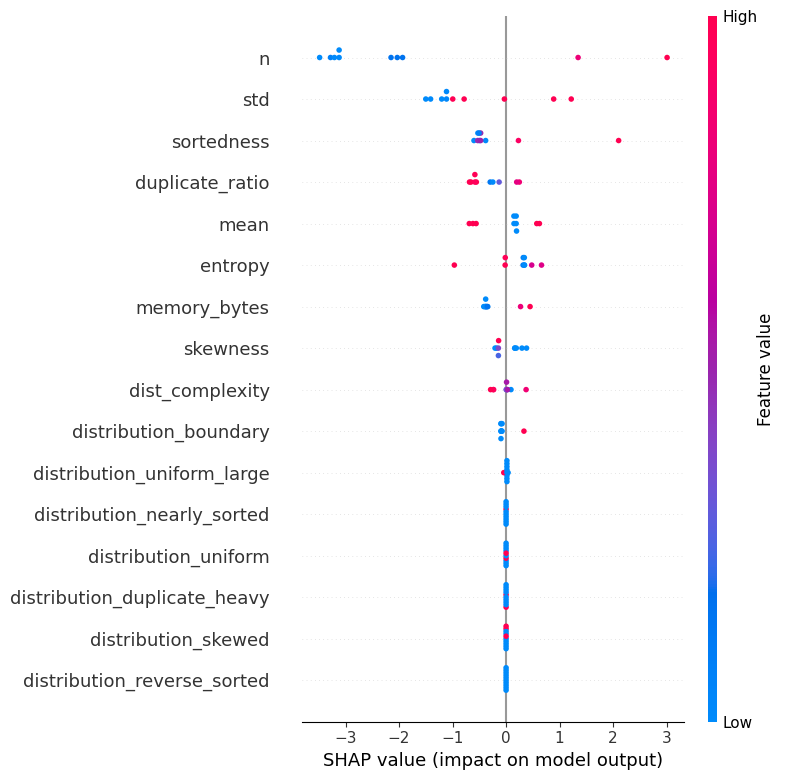

In [61]:
import matplotlib.pyplot as plt

# Summary plot (global importance)
shap.summary_plot(shap_values, X_sample)

Model prediction (0=CPU, 1=GPU): 0
GPU probability: 0.022829698


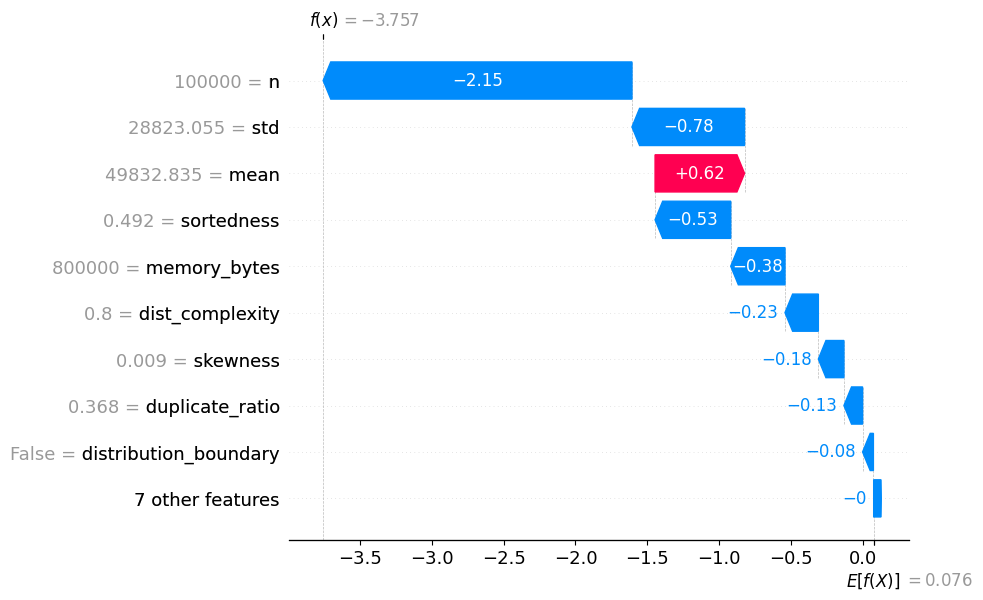

In [62]:
# Pick one example from X_sample
row_index = 0

print("Model prediction (0=CPU, 1=GPU):", xgb_model.predict(X_sample.iloc[[row_index]])[0])
print("GPU probability:", xgb_model.predict_proba(X_sample.iloc[[row_index]])[0][1])

# Waterfall plot for one prediction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[row_index],
        feature_names=X_sample.columns.tolist()
    )
)

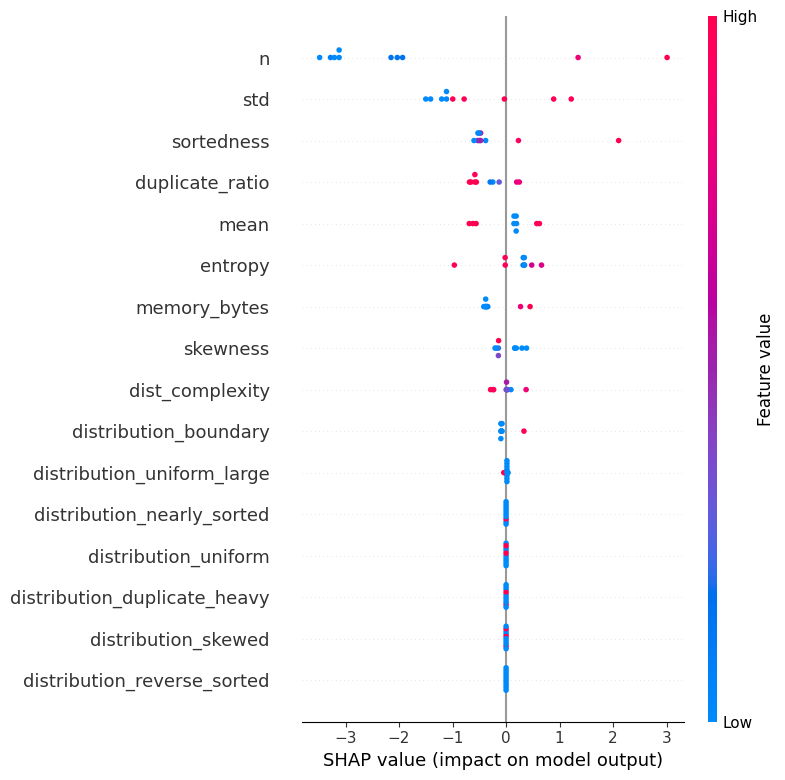

✅ Saved: results/plots/shap_summary_plot.png


In [63]:
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("results/plots/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: results/plots/shap_summary_plot.png")

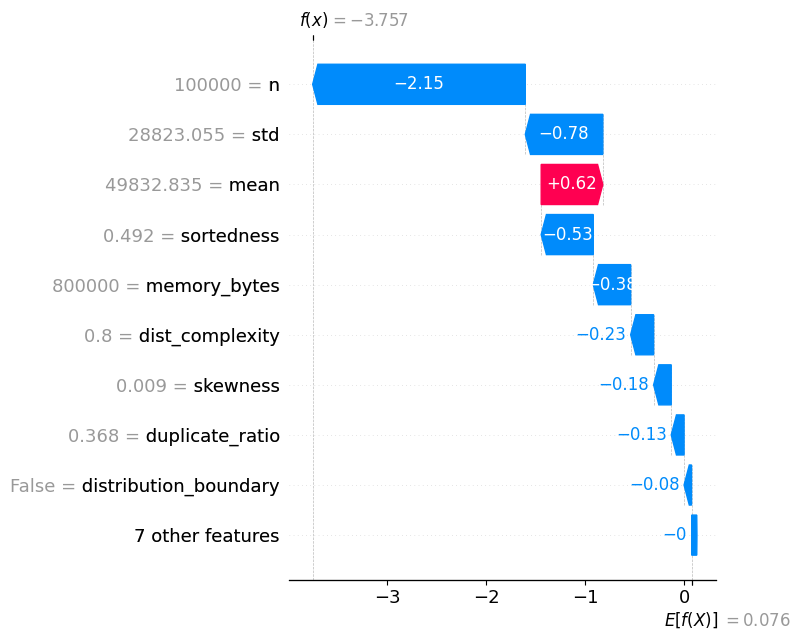

✅ Saved: results/plots/shap_waterfall_plot_row0.png


In [64]:
import matplotlib.pyplot as plt

row_index = 0

explanation = shap.Explanation(
    values=shap_values[row_index],
    base_values=explainer.expected_value,
    data=X_sample.iloc[row_index],
    feature_names=X_sample.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("results/plots/shap_waterfall_plot_row0.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: results/plots/shap_waterfall_plot_row0.png")

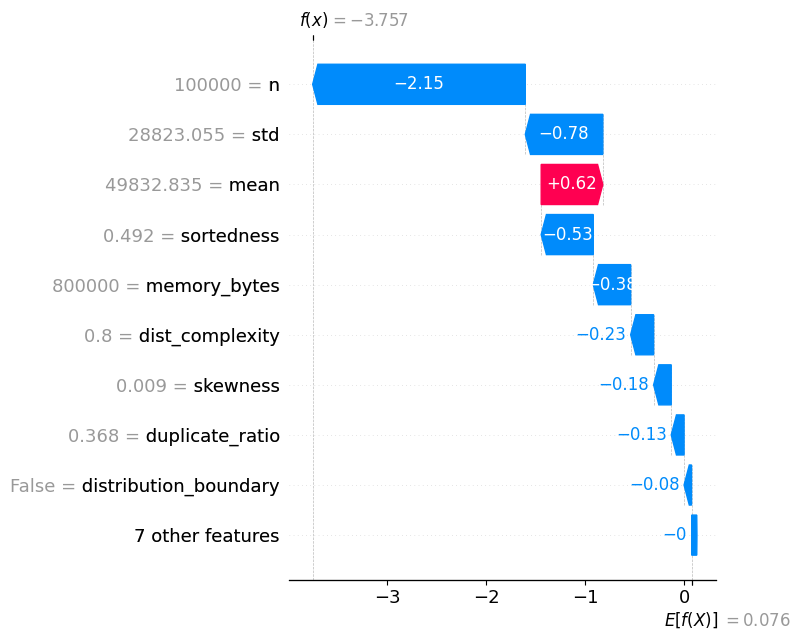

✅ Saved: results/plots/shap_waterfall_plot_row0.png


In [65]:
import matplotlib.pyplot as plt

row_index = 0

explanation = shap.Explanation(
    values=shap_values[row_index],
    base_values=explainer.expected_value,
    data=X_sample.iloc[row_index],
    feature_names=X_sample.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("results/plots/shap_waterfall_plot_row0.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: results/plots/shap_waterfall_plot_row0.png")

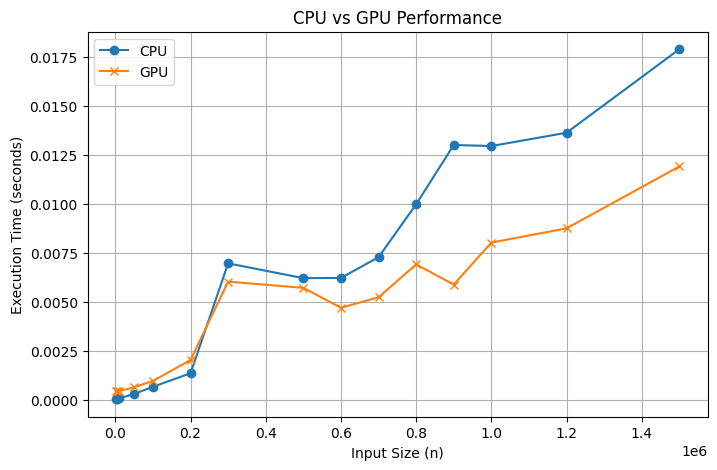

✅ Saved: results/plots/cpu_vs_gpu_clean.png
          n  cpu_time  gpu_total_time
0      1000  0.000024        0.000466
1      5000  0.000031        0.000427
2     10000  0.000062        0.000440
3     50000  0.000297        0.000636
4    100000  0.000657        0.000956
5    200000  0.001350        0.002025
6    300000  0.006958        0.006026
7    500000  0.006204        0.005709
8    600000  0.006214        0.004692
9    700000  0.007272        0.005225
10   800000  0.009975        0.006908
11   900000  0.013000        0.005877
12  1000000  0.012946        0.008019
13  1200000  0.013625        0.008744
14  1500000  0.017888        0.011906


In [67]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/benchmarks/benchmark_dataset_v5.csv")

# Keep only required numeric columns
df_grouped = (
    df.groupby("n")[["cpu_time", "gpu_total_time"]]
      .mean()
      .reset_index()
      .sort_values("n")
)

plt.figure(figsize=(8,5))
plt.plot(df_grouped["n"], df_grouped["cpu_time"], marker="o", label="CPU")
plt.plot(df_grouped["n"], df_grouped["gpu_total_time"], marker="x", label="GPU")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("CPU vs GPU Performance")
plt.legend()
plt.grid(True)

plt.savefig("results/plots/cpu_vs_gpu_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: results/plots/cpu_vs_gpu_clean.png")
print(df_grouped)

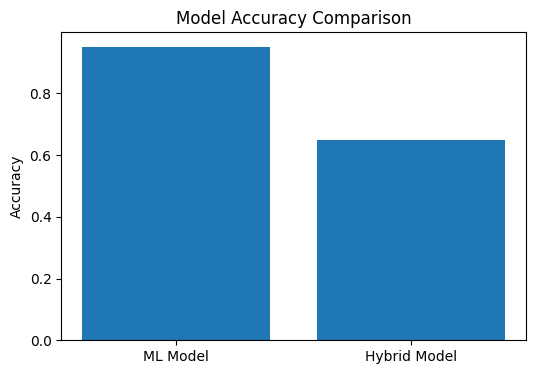

✅ Saved: results/plots/accuracy_comparison.png


In [68]:
labels = ["ML Model", "Hybrid Model"]
values = [large_df["correct"].mean(), hybrid_df["correct"].mean()]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.savefig("results/plots/accuracy_comparison.png", dpi=300)
plt.show()

print("✅ Saved: results/plots/accuracy_comparison.png")

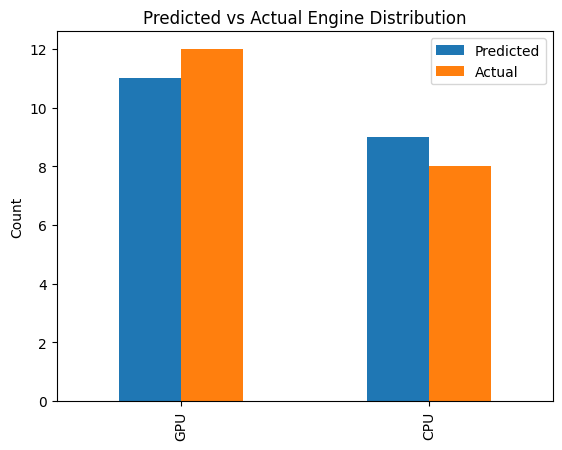

✅ Saved: results/plots/pred_vs_actual.png


In [69]:
pred_counts = large_df["predicted"].value_counts()
actual_counts = large_df["actual"].value_counts()

df_plot = pd.DataFrame({
    "Predicted": pred_counts,
    "Actual": actual_counts
}).fillna(0)

df_plot.plot(kind="bar")

plt.title("Predicted vs Actual Engine Distribution")
plt.ylabel("Count")

plt.savefig("results/plots/pred_vs_actual.png", dpi=300)
plt.show()

print("✅ Saved: results/plots/pred_vs_actual.png")

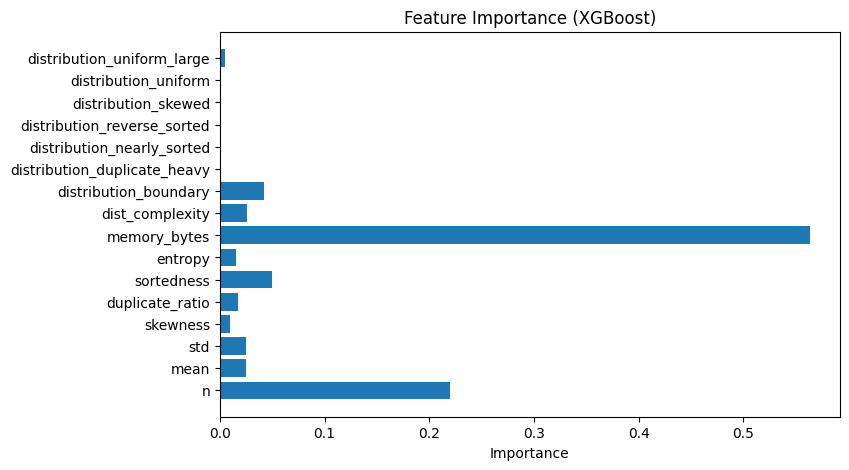

✅ Saved: results/plots/feature_importance.png


In [70]:
import numpy as np

importance = xgb_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(xgb_feature_columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")

plt.savefig("results/plots/feature_importance.png", dpi=300)
plt.show()

print("✅ Saved: results/plots/feature_importance.png")

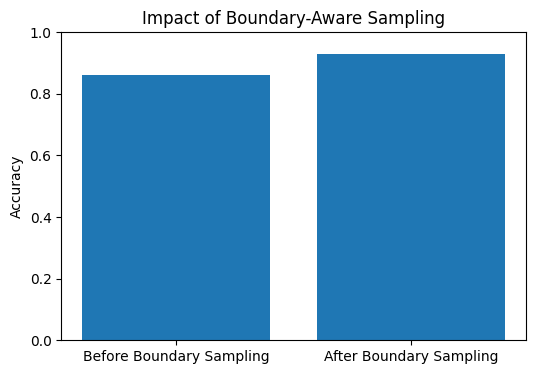

In [72]:
labels = ["Before Boundary Sampling", "After Boundary Sampling"]
values = [0.86, 0.93]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("Impact of Boundary-Aware Sampling")

plt.ylim(0,1)

plt.savefig("results/plots/boundary_sampling_impact.png", dpi=300, bbox_inches="tight")
plt.show()

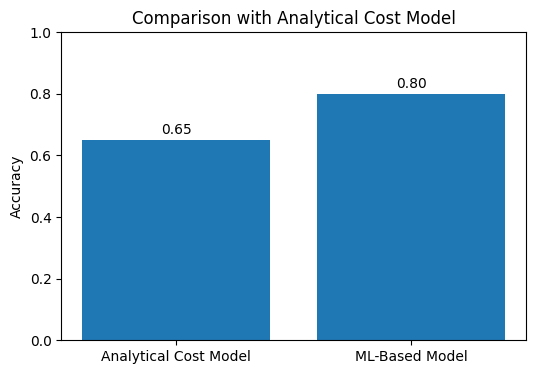

✅ Saved: results/plots/cost_model_comparison.png


In [73]:
import matplotlib.pyplot as plt

# Replace with your exact observed values if needed
labels = ["Analytical Cost Model", "ML-Based Model"]
values = [0.65, 0.80]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("Comparison with Analytical Cost Model")
plt.ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.savefig("results/plots/cost_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: results/plots/cost_model_comparison.png")

In [74]:
y_pred_ml=xgb_model.predict(X_test)
ml_accuracy=(y_pred_ml == y_test).mean()

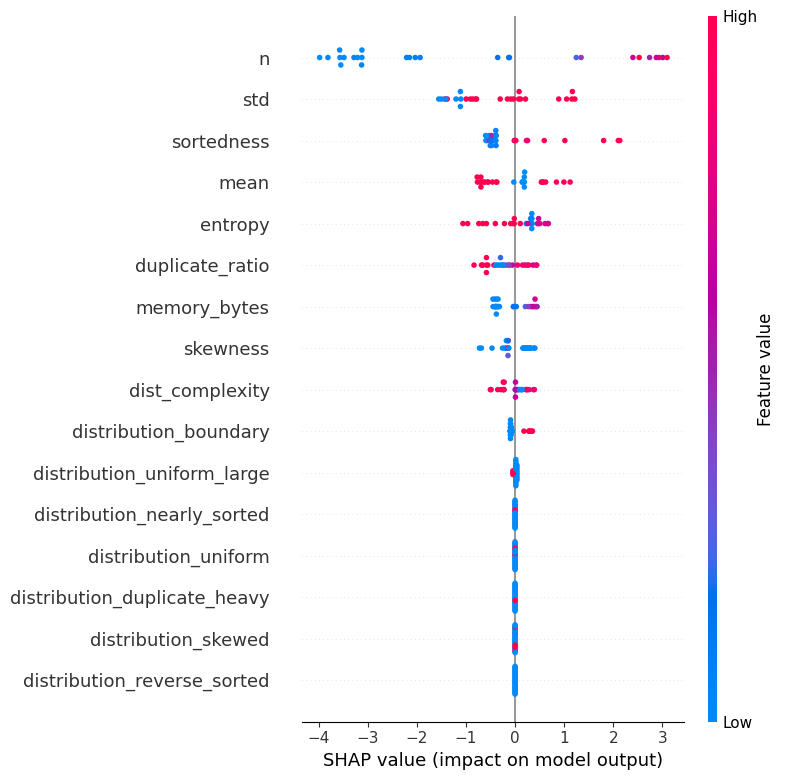

✅ Saved: shap_summary.png


In [75]:
import shap

# create explainer
explainer = shap.TreeExplainer(xgb_model)

# compute SHAP values
shap_values = explainer.shap_values(X_test)

# summary plot
shap.summary_plot(shap_values, X_test, show=False)

import matplotlib.pyplot as plt
plt.savefig("results/plots/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: shap_summary.png")